# **Training**

In [ ]:
import os
import shutil
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import f1_score as sk_f1

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# =========================
# 1. CONFIGURATION
# =========================

TRAIN_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/train_dataset.csv"
VAL_CSV   = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/val_dataset.csv"
TEST_CSV  = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/test_dataset.csv"

CFG = {
    "image_size":  384,
    "batch_size":   64,
    "epochs":       15,
    "lr":          1e-3,
    "wd":          0.0,

    "train_csv": TRAIN_CSV,
    "val_csv":   VAL_CSV,

    "save_path":  "/content/drive/MyDrive/FYP/paper_revision_v01/models/focinet_singleshot/baseline_model.pth",
    "output_dir": "/content/drive/MyDrive/FYP/paper_revision_v01/training_plots/focinet_singleshot",
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

DEVICE = CFG["device"]
print(f"--- FociNet VGG16 Baseline (Trained from Scratch) ---")
print(f"Image size : {CFG['image_size']}")
print(f"Batch size : {CFG['batch_size']}")
print(f"Epochs     : {CFG['epochs']}")
print(f"Device     : {DEVICE}")

--- FociNet VGG16 Baseline (Trained from Scratch) ---
Image size : 384
Batch size : 64
Epochs     : 15
Device     : cuda


In [ ]:
# =========================
# 2. DATA AUGMENTATIONS & DATASET
# =========================
# Same normalization as all other variants — computed from culture_only_v02 train split
NORM_MEAN = [0.2251, 0.2251, 0.2251]
NORM_STD  = [0.2375, 0.2375, 0.2375]

def get_transforms(img_size, is_train=True):
    if is_train:
        return transforms.Compose([
            transforms.Resize((img_size, img_size),
                              interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.RandomApply(
                [transforms.ColorJitter(brightness=0.1, contrast=0.1)], p=0.3
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size),
                              interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
        ])

class FociDataset(Dataset):
    def __init__(self, csv_path, img_size=384, is_train=True):
        self.df        = pd.read_csv(csv_path)
        self.transform = get_transforms(img_size, is_train)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img_p = str(row["image_path"])
            img   = Image.open(img_p).convert("RGB")
            x     = self.transform(img)
            y     = float(row["label"])
            return x, torch.tensor(y).float()
        except Exception: return None

def safe_collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return None
    xs, ys = zip(*batch)
    return torch.stack(xs), torch.stack(ys)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 240MB/s]


Model parameters: 139,574,337
Label counts — 0: 500, 1: 1500 | pos_weight: 3.000

Starting Training...


Epoch 1 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 13: Train Loss=0.1812, Acc=0.9235 | Val Loss=0.2629, Acc=0.8875, F1=0.8960 | LR: 4.42e-05


Epoch 14 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 14: Train Loss=0.1872, Acc=0.9205 | Val Loss=0.2588, Acc=0.8844, F1=0.8934 | LR: 1.19e-05


Epoch 15 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 15: Train Loss=0.1873, Acc=0.9260 | Val Loss=0.2542, Acc=0.8875, F1=0.8953 | LR: 1.00e-06

Copying per-epoch checkpoints to Drive...
✅ All checkpoints copied to Drive.

Training Complete! Best Val F1: 0.9245
Plot saved to /content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg16_scratch_v03/plots/training_metrics_focinet_vgg16.png


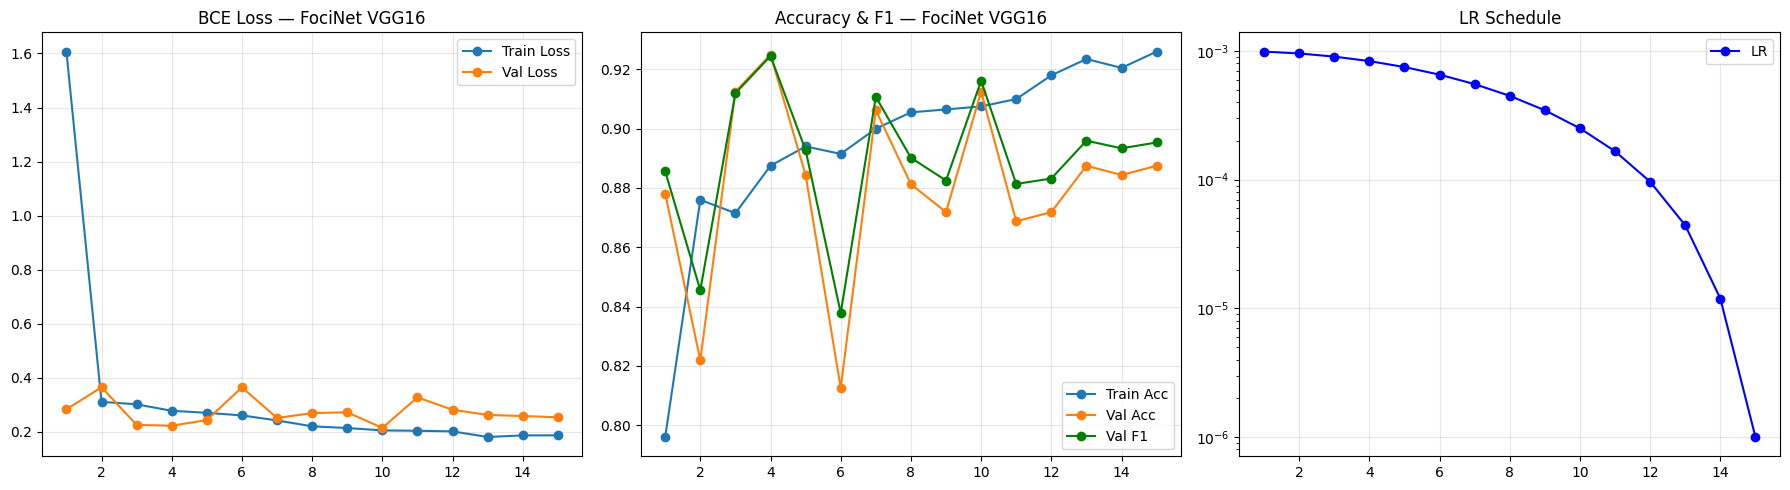

In [ ]:
# =========================
# 3. MODEL — FociNet architecture
# =========================
# FociNet uses VGG16 pretrained on ImageNet, with the classifier head
# replaced for binary classification. We follow their design exactly:
#   VGG16 feature extractor (pretrained=True, all layers trainable)
#   → AdaptiveAvgPool
#   → Classifier: FC(25088→4096) ReLU Dropout(0.5)
#                 FC(4096→4096)  ReLU Dropout(0.5)
#                 FC(4096→1)     ← binary output (no 3rd class)
# Reference: cellimnet et al. (2020)

# class FociNet_VGG16(nn.Module):
#     def __init__(self):
#         super().__init__()

#         # Load VGG16 with ImageNet weights
#         vgg = models.vgg16(pretrained=True)

#         # Keep the full feature extractor — all convolutional blocks
#         self.features = vgg.features          # (B, 512, H/32, W/32)
#         self.avgpool  = vgg.avgpool           # AdaptiveAvgPool2d(7, 7)

#         # Replace classifier with binary head
#         # FociNet uses same FC structure but binary output instead of 3-class
#         self.classifier = nn.Sequential(
#             nn.Linear(512 * 7 * 7, 4096),    # FC1 — same as FociNet
#             nn.ReLU(inplace=True),
#             nn.Dropout(p=0.5),
#             nn.Linear(4096, 4096),            # FC2 — same as FociNet
#             nn.ReLU(inplace=True),
#             nn.Dropout(p=0.5),
#             nn.Linear(4096, 1)                # binary output — no 3rd class
#         )

#         # Initialise new classifier layers with Xavier uniform
#         for m in self.classifier.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.xavier_uniform_(m.weight)
#                 nn.init.zeros_(m.bias)

#     def forward(self, x):
#         x = self.features(x)
#         x = self.avgpool(x)
#         x = torch.flatten(x, 1)
#         x = self.classifier(x)
#         return x.squeeze(-1)   # (B,) logit



class FociNet_VGG19(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(pretrained=True)

        # Freeze ALL convolutional layers (block_1 to block_5)
        # Paper: "fixed the weights of the convolutional layers"
        self.features = vgg.features
        for param in self.features.parameters():
            param.requires_grad = False

        self.avgpool = vgg.avgpool   # AdaptiveAvgPool2d(7,7)

        # Replace final FC layer: 3-class → binary
        # Paper uses 3 FC layers with ReLU → ReLU → Softmax
        # We replace Softmax with Sigmoid for binary BCE
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 1)    # binary — paper had 3, we use 1
        )
        # Only initialise the new FC head
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x.squeeze(-1)



# =========================
# 4. TRAINING LOOP
# =========================
def main():
    os.makedirs(os.path.dirname(CFG["save_path"]), exist_ok=True)
    os.makedirs(CFG["output_dir"], exist_ok=True)

    train_loader = DataLoader(
        FociDataset(CFG["train_csv"], CFG["image_size"], is_train=True),
        batch_size=CFG["batch_size"], shuffle=True,
        collate_fn=safe_collate, num_workers=0
    )
    val_loader = DataLoader(
        FociDataset(CFG["val_csv"], CFG["image_size"], is_train=False),
        batch_size=CFG["batch_size"], shuffle=False,
        collate_fn=safe_collate, num_workers=0
    )

    model = FociNet_VGG19().to(DEVICE)
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # All parameters trainable — full fine-tuning as in FociNet
    optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=CFG["lr"]
    )

    # Same cosine schedule as all other variants
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"], eta_min=1e-6
    )

    # pos_weight computed from actual train CSV — same as all other variants
    label_counts = pd.read_csv(TRAIN_CSV)["label"].value_counts()
    n0           = label_counts[0]
    n1           = label_counts[1]
    pos_weight   = torch.tensor([n1 / n0]).to(DEVICE)
    print(f"Label counts — 0: {n0}, 1: {n1} | pos_weight: {pos_weight.item():.3f}")
    criterion = nn.BCEWithLogitsLoss()

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  [],
        "val_f1":     [], "lr":       []
    }
    best_f1 = 0.0

    print("\nStarting Training...")
    for epoch in range(CFG["epochs"]):

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]", leave=False):
            if batch is None: continue
            x, y = [b.to(DEVICE) for b in batch]
            optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            loss.backward()
            optimizer.step()

            B          = x.size(0)
            t_loss    += loss.item() * B
            t_correct += ((logits >= 0.0).float() == y).sum().item()
            t_total   += B

        # ── Val ───────────────────────────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        v_preds_all, v_labels_all  = [], []

        with torch.no_grad():
            for batch in val_loader:
                if batch is None: continue
                x, y   = [b.to(DEVICE) for b in batch]
                logits = model(x)
                loss   = criterion(logits, y)

                B          = x.size(0)
                v_loss    += loss.item() * B
                v_correct += ((logits >= 0.0).float() == y).sum().item()
                v_total   += B

                v_preds_all.extend((logits >= 0.0).float().cpu().numpy())
                v_labels_all.extend(y.cpu().numpy())

        scheduler.step()

        lr_now         = optimizer.param_groups[0]["lr"]
        train_loss_avg = t_loss    / t_total
        val_loss_avg   = v_loss    / max(v_total, 1)
        train_acc_avg  = t_correct / t_total
        val_acc_avg    = v_correct / max(v_total, 1)
        val_f1         = sk_f1(v_labels_all, v_preds_all, zero_division=0)

        history["train_loss"].append(train_loss_avg)
        history["val_loss"].append(val_loss_avg)
        history["train_acc"].append(train_acc_avg)
        history["val_acc"].append(val_acc_avg)
        history["val_f1"].append(val_f1)
        history["lr"].append(lr_now)

        print(
            f"Epoch {epoch+1:02d}: "
            f"Train Loss={train_loss_avg:.4f}, Acc={train_acc_avg:.4f} | "
            f"Val Loss={val_loss_avg:.4f}, Acc={val_acc_avg:.4f}, F1={val_f1:.4f} | "
            f"LR: {lr_now:.2e}"
        )

        if val_f1 >= best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), CFG["save_path"])
            print(f"  -> ✅ Saved Best Model (Val F1: {best_f1:.4f})")

        torch.save(model.state_dict(), f"/content/ckpt_focinet_epoch_{epoch+1}.pth")

    # ── Copy checkpoints to Drive ─────────────────────────────────────────────
    print("\nCopying per-epoch checkpoints to Drive...")
    for ep in range(1, CFG["epochs"] + 1):
        local_ckpt = f"/content/ckpt_focinet_epoch_{ep}.pth"
        if os.path.exists(local_ckpt):
            shutil.copy2(
                local_ckpt,
                CFG["save_path"].replace(".pth", f"_epoch_{ep}.pth")
            )
            os.remove(local_ckpt)
    print("✅ All checkpoints copied to Drive.")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, CFG["epochs"] + 1)

    ax[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
    ax[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o")
    ax[0].set_title("BCE Loss — FociNet VGG16")
    ax[0].legend(); ax[0].grid(True, alpha=0.3)

    ax[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
    ax[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   marker="o")
    ax[1].plot(epochs_range, history["val_f1"],    label="Val F1",    marker="o", color="green")
    ax[1].set_title("Accuracy & F1 — FociNet VGG16")
    ax[1].legend(); ax[1].grid(True, alpha=0.3)

    ax[2].plot(epochs_range, history["lr"], label="LR", marker="o", color="blue")
    ax[2].set_title("LR Schedule")
    ax[2].set_yscale("log"); ax[2].legend(); ax[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = f"{CFG['output_dir']}/training_metrics_focinet_vgg16.png"
    plt.savefig(plot_path)
    print(f"\nTraining Complete! Best Val F1: {best_f1:.4f}")
    print(f"Plot saved to {plot_path}")

# Auto-runner disabled — cell 3 now only defines the model and main().
# To use single-shot training, call main() explicitly. For the reviewer
# fix (5 seeds), run the multi-seed training cell instead.
# if __name__ == "__main__":
#     main()


In [ ]:
# =========================================================
# MULTI-SEED FOCINET TRAINING (reviewer fix)
# =========================================================
# Re-trains FociNet 5 times with different random seeds on the same splits,
# matching the protocol used for the proposed method. Writes one checkpoint
# per seed; existing checkpoints are skipped so the cell is safe to re-run.
#
# Depends on: FociNet_VGG19 class, FociDataset, safe_collate, get_transforms,
#             CFG, DEVICE (all defined in cells 1-3).

import random

N_SEEDS_FOCINET     = 5
FOCINET_MODELS_DIR  = "/content/drive/MyDrive/FYP/paper_revision_v01/models/focinet"
FOCINET_PLOTS_DIR   = "/content/drive/MyDrive/FYP/paper_revision_v01/training_plots/focinet"
os.makedirs(FOCINET_MODELS_DIR, exist_ok=True)
os.makedirs(FOCINET_PLOTS_DIR, exist_ok=True)


def set_all_seeds_focinet(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


def focinet_save_path(seed):
    return os.path.join(FOCINET_MODELS_DIR, f"focinet_seed{seed}.pth")


def train_focinet_seed(seed):
    save_path = focinet_save_path(seed)
    if os.path.exists(save_path):
        print(f"[skip] FociNet seed {seed} already exists at {save_path}")
        return {"seed": seed, "ckpt": save_path, "best_val_f1": None, "skipped": True}

    print("\n" + "#"*60)
    print(f"  Training FociNet seed {seed}")
    print("#"*60)
    set_all_seeds_focinet(seed)

    train_loader = DataLoader(
        FociDataset(CFG["train_csv"], CFG["image_size"], is_train=True),
        batch_size=CFG["batch_size"], shuffle=True,
        collate_fn=safe_collate, num_workers=0,
    )
    val_loader = DataLoader(
        FociDataset(CFG["val_csv"], CFG["image_size"], is_train=False),
        batch_size=CFG["batch_size"], shuffle=False,
        collate_fn=safe_collate, num_workers=0,
    )

    model = FociNet_VGG19().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"], eta_min=1e-6,
    )
    criterion = nn.BCEWithLogitsLoss()

    best_f1 = 0.0
    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(CFG["epochs"]):
        model.train()
        t_loss, t_n = 0.0, 0
        for batch in tqdm(train_loader, desc=f"focinet s{seed} ep{epoch+1}", leave=False):
            if batch is None: continue
            x, y = [b.to(DEVICE) for b in batch]
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * x.size(0); t_n += x.size(0)

        model.eval()
        v_loss, v_preds, v_labels = 0.0, [], []
        with torch.no_grad():
            for batch in val_loader:
                if batch is None: continue
                x, y = [b.to(DEVICE) for b in batch]
                logits = model(x)
                v_loss += criterion(logits, y).item() * x.size(0)
                v_preds.extend((logits >= 0.0).float().cpu().numpy())
                v_labels.extend(y.cpu().numpy())
        scheduler.step()

        val_f1 = sk_f1(v_labels, v_preds, zero_division=0)
        history["train_loss"].append(t_loss / max(t_n, 1))
        history["val_loss"].append(v_loss / max(len(v_labels), 1))
        history["val_f1"].append(val_f1)
        print(f"  s{seed} ep{epoch+1:02d}: train_loss={t_loss/max(t_n,1):.4f} val_f1={val_f1:.4f}")

        if val_f1 >= best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), save_path)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, CFG["epochs"] + 1)
    ax[0].plot(ep, history["train_loss"], marker="o", label="train")
    ax[0].plot(ep, history["val_loss"], marker="o", label="val")
    ax[0].set_title(f"BCE loss (focinet seed {seed})"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(ep, history["val_f1"], marker="o", color="green")
    ax[1].set_title(f"Val F1 (focinet seed {seed})"); ax[1].grid(alpha=.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FOCINET_PLOTS_DIR, f"focinet_training_seed{seed}.png"))
    plt.close()

    print(f"  done s{seed}: best val F1 = {best_f1:.4f}  ->  {save_path}")
    return {"seed": seed, "ckpt": save_path, "best_val_f1": float(best_f1), "skipped": False}


if __name__ == "__main__":
    summary = []
    for s in range(N_SEEDS_FOCINET):
        summary.append(train_focinet_seed(s))
    print("\n" + "="*60)
    print("  Multi-seed FociNet training complete")
    print("="*60)
    for r in summary:
        tag = "skipped" if r["skipped"] else f"best val F1 = {r['best_val_f1']:.4f}"
        print(f"  focinet seed {r['seed']}: {tag}")


# **Eval**

In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

# =========================
# 1. CONFIGURATION
# =========================
TEST_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/test_dataset.csv"

CFG = {
    "batch_size":    32,
    "test_csv":      TEST_CSV,
    "model_ckpt": "/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg16_scratch_v03/baseline_model.pth",
    "output_dir": "/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg16_scratch_v03/eval_results/test_v01",
    "image_size":    384,
    "device":        torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

DEVICE = CFG["device"]
os.makedirs(CFG["output_dir"], exist_ok=True)

print(f"--- EVALUATION: FociNet VGG16 ---")
print(f"Checkpoint : {CFG['model_ckpt']}")
print(f"Test CSV   : {CFG['test_csv']}")

# =========================
# 2. DATASET
# =========================
# Same normalization as training — culture_only_v02 train split stats
NORM_MEAN = [0.2251, 0.2251, 0.2251]
NORM_STD  = [0.2375, 0.2375, 0.2375]

eval_transform = transforms.Compose([
    transforms.Resize((CFG["image_size"], CFG["image_size"]),
                      interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN, std=NORM_STD)
])

class FociEvalDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img_p = str(row["image_path"])
            img   = Image.open(img_p).convert("RGB")
            x     = eval_transform(img)
            y     = float(row["label"])
            return x, torch.tensor(y).float()
        except Exception: return None

def safe_collate_eval(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return None
    xs, ys = zip(*batch)
    return torch.stack(xs), torch.stack(ys)

# =========================
# 3. MODEL — must mirror training exactly
# =========================
class FociNet_VGG19(nn.Module):
    def __init__(self):
        super().__init__()
        vgg             = models.vgg19(pretrained=False)  # pretrained=False for eval
        self.features   = vgg.features
        for param in self.features.parameters():
            param.requires_grad = False
        self.avgpool    = vgg.avgpool
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x.squeeze(-1)

# =========================
# 4. EVALUATION
# =========================
def evaluate():
    test_loader = DataLoader(
        FociEvalDataset(CFG["test_csv"]),
        batch_size=CFG["batch_size"],
        shuffle=False,
        collate_fn=safe_collate_eval,
        num_workers=0
    )

    model = FociNet_VGG19().to(DEVICE)
    model.load_state_dict(
        torch.load(CFG["model_ckpt"], map_location=DEVICE),
        strict=True
    )
    model.eval()
    print("✅ Model loaded successfully")

    all_probs, all_labels = [], []

    print("Running inference...")
    with torch.no_grad():
        for batch in tqdm(test_loader):
            if batch is None: continue
            x, y = [b.to(DEVICE) for b in batch]
            logits = model(x)
            probs  = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # ── Metrics ──────────────────────────────────────────────────────────────
    y_true  = np.array(all_labels).astype(int)
    y_probs = np.array(all_probs)
    y_preds = (y_probs >= 0.5).astype(int)

    acc     = accuracy_score(y_true, y_preds)
    prec    = precision_score(y_true, y_preds, zero_division=0)
    rec     = recall_score(y_true, y_preds, zero_division=0)
    f1      = f1_score(y_true, y_preds, zero_division=0)
    roc_auc = auc(*roc_curve(y_true, y_probs)[:2])

    print("\n" + "="*42)
    print(f"  RESULTS — FociNet VGG16")
    print("="*42)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC AUC   : {roc_auc:.4f}")
    print("="*42)

    # Save metrics
    with open(os.path.join(CFG["output_dir"], "metrics.txt"), "w") as f:
        f.write(f"Model      : FociNet VGG16 (trained from scratch)\n")
        f.write(f"Checkpoint : {CFG['model_ckpt']}\n")
        f.write(f"Test CSV   : {CFG['test_csv']}\n\n")
        f.write(f"Accuracy   : {acc:.4f}\n")
        f.write(f"Precision  : {prec:.4f}\n")
        f.write(f"Recall     : {rec:.4f}\n")
        f.write(f"F1 Score   : {f1:.4f}\n")
        f.write(f"ROC AUC    : {roc_auc:.4f}\n")

    # ── Confusion matrix ─────────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Healthy", "Damaged"],
                yticklabels=["Healthy", "Damaged"])
    plt.xlabel("Predicted"); plt.ylabel("Ground Truth")
    plt.title("Confusion Matrix — FociNet VGG16")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG["output_dir"], "confusion_matrix.png"))
    plt.close()

    # ── ROC curve ────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — FociNet VGG16")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG["output_dir"], "roc_curve.png"))
    plt.close()

    print(f"\n✅ Done. Results saved to:\n{CFG['output_dir']}")


if __name__ == "__main__":
    evaluate()

--- EVALUATION: FociNet VGG16 ---
Checkpoint : /content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg16_scratch_v03/baseline_model.pth
Test CSV   : /content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/test_dataset.csv


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully
Running inference...


  0%|          | 0/11 [00:00<?, ?it/s]


  RESULTS — FociNet VGG16
  Accuracy  : 0.8571
  Precision : 0.8859
  Recall    : 0.8199
  F1 Score  : 0.8516
  ROC AUC   : 0.9400

✅ Done. Results saved to:
/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg16_scratch_v03/eval_results/test_v01


In [ ]:
# =========================================================
# MULTI-SEED FOCINET EVAL
# =========================================================


import json
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc,
    average_precision_score, precision_recall_curve,
)

FOCINET_EVAL_DIR = "/content/drive/MyDrive/FYP/paper_revision_v01/eval_results_focinet"
os.makedirs(FOCINET_EVAL_DIR, exist_ok=True)

BOOTSTRAP_SEED = 12345
N_BOOTSTRAP    = 1000


def _infer_focinet(model, csv_path):
    """Run FociNet on a CSV split. Returns (y_true, probs, paths)."""
    loader = DataLoader(
        FociDataset(csv_path, CFG["image_size"], is_train=False),
        batch_size=CFG["batch_size"], shuffle=False,
        collate_fn=safe_collate, num_workers=0,
    )
    df = pd.read_csv(csv_path)
    paths = df["image_path"].tolist()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False):
            if batch is None: continue
            x, y = [b.to(DEVICE) for b in batch]
            logits = model(x)
            probs  = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy().tolist())
            all_labels.extend(y.cpu().numpy().tolist())
    return (np.array(all_labels).astype(int),
            np.array(all_probs).astype(float),
            paths[:len(all_labels)])


def _metrics_at(y, p, tau):
    yh = (p >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yh, labels=[0, 1]).ravel()
    return {
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "accuracy":    float(accuracy_score(y, yh)),
        "precision":   float(precision_score(y, yh, zero_division=0)),
        "recall":      float(recall_score(y, yh, zero_division=0)),
        "f1":          float(f1_score(y, yh, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) else 0.0,
    }


def _agg(values):
    v = np.array(values, dtype=float)
    return {"mean": float(np.mean(v)),
            "sd":   float(np.std(v, ddof=1)) if len(v) > 1 else 0.0,
            "per_seed": v.tolist()}


def _boot_ci(y, p, tau, n_boot, rng):
    n = len(y)
    pool = {"f1": [], "precision": [], "recall": [], "accuracy": [],
            "specificity": [], "roc_auc": [], "pr_auc": []}
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, yp = y[idx], p[idx]
        if len(np.unique(yt)) < 2: continue
        m = _metrics_at(yt, yp, tau)
        try:
            fpr_b, tpr_b, _ = roc_curve(yt, yp)
            roc_a = float(auc(fpr_b, tpr_b))
            pr_a  = float(average_precision_score(yt, yp))
        except Exception:
            continue
        for k in ("f1", "precision", "recall", "accuracy", "specificity"):
            pool[k].append(m[k])
        pool["roc_auc"].append(roc_a)
        pool["pr_auc"].append(pr_a)
    return {k: list(v) for k, v in pool.items()}


N_SEEDS_FOCINET = 5
print(">>> Multi-seed FociNet evaluation\n")
rng = np.random.default_rng(BOOTSTRAP_SEED)
per_seed = []
for seed in range(N_SEEDS_FOCINET):
    ckpt = focinet_save_path(seed)
    if not os.path.exists(ckpt):
        raise FileNotFoundError(
            f"Missing FociNet seed {seed}: {ckpt}. Run the multi-seed training cell first."
        )
    print(f"seed {seed}: loading {ckpt}")
    model = FociNet_VGG19().to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()

    y_t, p_t, paths = _infer_focinet(model, TEST_CSV)
    seed_dir = os.path.join(FOCINET_EVAL_DIR, f"seed_{seed}")
    os.makedirs(seed_dir, exist_ok=True)
    pd.DataFrame({"image_path": paths, "label": y_t, "prob": p_t}) \
        .to_csv(os.path.join(seed_dir, "predictions_test.csv"), index=False)

    fpr, tpr, _ = roc_curve(y_t, p_t)
    roc_a = float(auc(fpr, tpr))
    pr_a  = float(average_precision_score(y_t, p_t))
    m05 = _metrics_at(y_t, p_t, 0.5)
    boot = _boot_ci(y_t, p_t, 0.5, N_BOOTSTRAP, rng)

    per_seed.append({
        "seed": seed, "roc_auc": roc_a, "pr_auc": pr_a,
        "at_tau_0.5": m05,
        "boot": boot,
    })
    print(f"  s{seed}: ROC-AUC={roc_a:.4f}  PR-AUC={pr_a:.4f}  "
          f"F1@0.5={m05['f1']:.3f}  TP={m05['tp']}  FP={m05['fp']}  "
          f"FN={m05['fn']}  TN={m05['tn']}")


def _gather(field, op_block=None):
    if op_block is None:
        return [s[field] for s in per_seed]
    return [s[op_block][field] for s in per_seed]


def _pool_boot(metric):
    out = []
    for s in per_seed:
        out.extend(s["boot"][metric])
    return out


def _boot_pct(values):
    if not values: return [float("nan"), float("nan")]
    lo, hi = np.percentile(values, [2.5, 97.5])
    return [float(lo), float(hi)]


headline = {
    "roc_auc": {**_agg(_gather("roc_auc")), "ci_bootstrap": _boot_pct(_pool_boot("roc_auc"))},
    "pr_auc":  {**_agg(_gather("pr_auc")),  "ci_bootstrap": _boot_pct(_pool_boot("pr_auc"))},
}
op05 = {}
for metric in ("accuracy", "precision", "recall", "f1", "specificity"):
    op05[metric] = {**_agg(_gather(metric, "at_tau_0.5")),
                    "ci_bootstrap": _boot_pct(_pool_boot(metric))}
for c in ("tp", "fp", "fn", "tn"):
    vals = _gather(c, "at_tau_0.5")
    op05[c] = {"mean": float(np.mean(vals)),
               "sd":   float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
               "per_seed": vals}

# Strip raw bootstrap arrays from JSON.
per_seed_lean = [{k: v for k, v in s.items() if k != "boot"} for s in per_seed]

focinet_numbers = {
    "config": {"n_seeds": N_SEEDS_FOCINET, "n_bootstrap": N_BOOTSTRAP, "test_csv": TEST_CSV},
    "headline":  headline,
    "at_tau_0.5": op05,
    "per_seed":  per_seed_lean,
}
with open(os.path.join(FOCINET_EVAL_DIR, "focinet_paper_numbers.json"), "w") as f:
    json.dump(focinet_numbers, f, indent=2)


def _pm(b):  return f"{b['mean']:.3f} +- {b['sd']:.3f}"
def _ci(b):  return f"95% CI [{b['ci_bootstrap'][0]:.3f}, {b['ci_bootstrap'][1]:.3f}]"
def _cnt(b): return f"{b['mean']:.1f} +- {b['sd']:.1f}"

md = []
md.append(f"# FociNet multi-seed results ({N_SEEDS_FOCINET} seeds)\n")
md.append("PR-AUC = average precision; reported as a single quantity.\n")
md.append("---\n")
md.append("## Headline (threshold-free)\n")
md.append(f"- ROC-AUC: {_pm(headline['roc_auc'])} ({_ci(headline['roc_auc'])})")
md.append(f"- PR-AUC:  {_pm(headline['pr_auc'])} ({_ci(headline['pr_auc'])})")
md.append("\n## At tau = 0.5\n")
for k in ("f1", "precision", "recall", "accuracy", "specificity"):
    md.append(f"- {k}: {_pm(op05[k])} ({_ci(op05[k])})")
md.append(f"- Confusion: TP {_cnt(op05['tp'])}, FP {_cnt(op05['fp'])}, "
          f"FN {_cnt(op05['fn'])}, TN {_cnt(op05['tn'])}\n")
with open(os.path.join(FOCINET_EVAL_DIR, "focinet_paper_numbers.md"), "w",
          encoding="utf-8") as f:
    f.write("\n".join(md))

print("\n" + "="*60)
print("  FociNet multi-seed summary @ tau=0.5")
print("="*60)
print(f"  ROC-AUC : {_pm(headline['roc_auc'])}  {_ci(headline['roc_auc'])}")
print(f"  PR-AUC  : {_pm(headline['pr_auc'])}  {_ci(headline['pr_auc'])}")
print(f"  F1      : {_pm(op05['f1'])}")
print(f"  Precision : {_pm(op05['precision'])}")
print(f"  Recall    : {_pm(op05['recall'])}")
print(f"  Accuracy  : {_pm(op05['accuracy'])}")
print(f"\nArtifacts in {FOCINET_EVAL_DIR}")


# **Zeroshot eval**

In [ ]:
# Cell 1 — mount drive
from google.colab import drive
drive.mount("/content/drive")

# Cell 2 — clone repo and unzip weights
!git clone https://github.com/cellimnet/FociNet.git
!ls /content/FociNet/asset/
!cd /content/FociNet/asset && unzip VGG.zip
!ls /content/FociNet/asset/   # should show VGG.h5

# Cell 3 — install TF if needed
!pip install tensorflow==2.12.0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'FociNet'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 113 (delta 11), reused 7 (delta 3), pack-reused 92 (from 1)
Receiving objects: 100% (113/113), 143.64 MiB | 22.95 MiB/s, done.
Resolving deltas: 100% (28/28), done.
Unet_deenv.h5  Unet_seg.h5  VGG.zip
Archive:  VGG.zip
  inflating: VGG.h5                  
Unet_deenv.h5  Unet_seg.h5  VGG.h5  VGG.zip
ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.12.0


In [ ]:
# ============================================================
# FociNet Zero-Shot Evaluation on culture_only_v02 test set
# ============================================================
# Steps:
#  1. Clone FociNet repo and download VGG.h5 weights
#  2. Load pretrained Keras model (TF2 compat mode)
#  3. Apply FociNet preprocessing (contrast stretching)
#  4. Run inference — 3 class output (0=normal, 1=damaged, 2=pointless)
#  5. Map to binary: class 1 → damaged, class 0 + class 2 → healthy
#  6. Compute metrics and save results
# ============================================================

# =========================
# STEP 1 — Install and download
# =========================
# Run these in separate Colab cells before running the script

# !pip install tensorflow==2.12.0   # TF2 can load TF1 Keras .h5 files
# !git clone https://github.com/cellimnet/FociNet.git
# !cd FociNet && ls asset/           # check if VGG.zip is present
# !cd FociNet/asset && unzip VGG.zip # unzip to get VGG.h5

# =========================
# STEP 2 — Imports
# =========================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)

print(f"TensorFlow version: {tf.__version__}")

# =========================
# STEP 3 — CONFIGURATION
# =========================
TEST_CSV    = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/test_dataset.csv"
MODEL_PATH  = "/content/FociNet/asset/VGG.h5"          # path after unzip
OUTPUT_DIR  = "/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_zeroshot/eval_results"

IMAGE_SIZE  = 256   # FociNet uses 256×256 as stated in paper
BATCH_SIZE  = 32

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Model path : {MODEL_PATH}")
print(f"Test CSV   : {TEST_CSV}")
print(f"Output dir : {OUTPUT_DIR}")

TensorFlow version: 2.19.0
Model path : /content/FociNet/asset/VGG.h5
Test CSV   : /content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/test_dataset.csv
Output dir : /content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_zeroshot/eval_results


In [ ]:
# =========================
# STEP 4 — PREPROCESSING
# =========================

def focinet_preprocess(img_path, size=256):
    """
    FociNet preprocessing module:
    - Resize to size×size
    - Contrast stretching: 0.01 percentile to 99.99 percentile → [0,1]
    - Expand to 3-channel RGB (FociNet expects RGB input)
    """
    img  = Image.open(img_path).convert("RGB")
    img  = img.resize((size, size), Image.BICUBIC)
    arr  = np.array(img).astype(np.float32)

    # Contrast stretching — FociNet style
    p_low  = np.percentile(arr, 0.01)
    p_high = np.percentile(arr, 99.99)
    arr    = (arr - p_low) / (p_high - p_low + 1e-6)
    arr    = np.clip(arr, 0.0, 1.0)

    return arr   # (256, 256, 3) in [0, 1]

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 8, 8, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   134,221,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │        12,291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,039,811 (652.47 MB)

 Trainable params: 151,015,427 (576.08 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

ValueError: Layer count mismatch when loading weights from file. Model expected 4 layers, found 17 saved layers.

In [ ]:
import tensorflow as tf

# Build flat model — layer names match h5 file exactly
inputs = tf.keras.Input(shape=(256, 256, 3), name="input_1")

# Block 1
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu", name="block1_conv1")(inputs)
x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu", name="block1_conv2")(x)
x = tf.keras.layers.MaxPooling2D(2, 2, name="block1_pool")(x)

# Block 2
x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu", name="block2_conv1")(x)
x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu", name="block2_conv2")(x)
x = tf.keras.layers.MaxPooling2D(2, 2, name="block2_pool")(x)

# Block 3
x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu", name="block3_conv1")(x)
x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu", name="block3_conv2")(x)
x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu", name="block3_conv3")(x)
x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu", name="block3_conv4")(x)
x = tf.keras.layers.MaxPooling2D(2, 2, name="block3_pool")(x)

# Block 4
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu", name="block4_conv1")(x)
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu", name="block4_conv2")(x)
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu", name="block4_conv3")(x)
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu", name="block4_conv4")(x)
x = tf.keras.layers.MaxPooling2D(2, 2, name="block4_pool")(x)

# Block 5
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu", name="block5_conv1")(x)
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu", name="block5_conv2")(x)
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu", name="block5_conv3")(x)
x = tf.keras.layers.Conv2D(512, 3, padding="same", activation="relu", name="block5_conv4")(x)
x = tf.keras.layers.MaxPooling2D(2, 2, name="block5_pool")(x)

# FC head — stored under "model" key in h5
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(4096, activation="relu", name="dense")(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(4096, activation="relu", name="dense_1")(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(3,    activation="softmax", name="dense_2")(x)

model = tf.keras.Model(inputs=inputs, outputs=x)

# Load weights by name — now layer names match h5 exactly
model.load_weights("/content/FociNet/asset/VGG.h5", by_name=True)
print("✅ Weights loaded successfully")
print(f"Output shape: {model.output_shape}")

✅ Weights loaded successfully
Output shape: (None, 3)


In [ ]:
# =========================
# STEP 6 — INFERENCE
# =========================
df_test = pd.read_csv(TEST_CSV)
print(f"\nTest set size: {len(df_test)} images")

all_probs_class0  = []   # P(normal)
all_probs_class1  = []   # P(damaged)
all_probs_class2  = []   # P(pointless/nonsignaling)
all_labels        = []
failed            = 0

print("Running zero-shot inference...")
for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    try:
        img_path = str(row["image_path"])
        gt_label = int(row["label"])

        # Preprocess
        x = focinet_preprocess(img_path, size=IMAGE_SIZE)
        x = np.expand_dims(x, axis=0)   # (1, 256, 256, 3)

        # Predict — returns (1, 3) softmax probabilities
        probs = model.predict(x, verbose=0)[0]   # (3,)

        all_probs_class0.append(float(probs[0]))
        all_probs_class1.append(float(probs[1]))
        all_probs_class2.append(float(probs[2]))
        all_labels.append(gt_label)

    except Exception as e:
        print(f"  ⚠️  Skipped {img_path}: {e}")
        failed += 1

print(f"\nInference complete. Failed: {failed} / {len(df_test)}")


Test set size: 322 images
Running zero-shot inference...


  0%|          | 0/322 [00:00<?, ?it/s]


Inference complete. Failed: 0 / 322


In [ ]:
# =========================
# STEP 7 — BINARY MAPPING
# =========================
# Class mapping for binary evaluation:
#   class 0 (normal)      → 0 (healthy)
#   class 1 (damaged)     → 1 (damaged)
#   class 2 (pointless)   → 0 (healthy)  ← treated as healthy per user request
#
# Binary probability of damaged = P(class 1)
# Binary prediction = argmax treating class 0+class 2 as healthy

y_true         = np.array(all_labels).astype(int)
probs_class0   = np.array(all_probs_class0)
probs_class1   = np.array(all_probs_class1)
probs_class2   = np.array(all_probs_class2)

# Raw 3-class argmax
pred_3class    = np.argmax(
    np.stack([probs_class0, probs_class1, probs_class2], axis=1),
    axis=1
)

# Binary prediction: 1 if argmax==1, else 0 (class 2 → 0)
y_preds        = (pred_3class == 1).astype(int)

# Binary probability for ROC AUC — use P(class 1) directly
# since class 2 is treated as healthy this is the most natural choice
y_probs_binary = probs_class1

# =========================
# STEP 8 — METRICS
# =========================
acc     = accuracy_score(y_true, y_preds)
prec    = precision_score(y_true, y_preds, zero_division=0)
rec     = recall_score(y_true, y_preds, zero_division=0)
f1      = f1_score(y_true, y_preds, zero_division=0)
roc_auc = auc(*roc_curve(y_true, y_probs_binary)[:2])

# Class 2 statistics
n_class2 = int((pred_3class == 2).sum())

print("\n" + "="*50)
print("  RESULTS — FociNet Zero-Shot Evaluation")
print("="*50)
print(f"  Total test images     : {len(y_true)}")
print(f"  Predicted class 2     : {n_class2} ({n_class2/len(y_true)*100:.1f}%) → treated as healthy")
print(f"  Accuracy              : {acc:.4f}")
print(f"  Precision             : {prec:.4f}")
print(f"  Recall                : {rec:.4f}")
print(f"  F1 Score              : {f1:.4f}")
print(f"  ROC AUC               : {roc_auc:.4f}")
print("="*50)

# =========================
# STEP 9 — SAVE RESULTS
# =========================
with open(os.path.join(OUTPUT_DIR, "metrics.txt"), "w") as f:
    f.write("Model      : FociNet pretrained (zero-shot, no retraining)\n")
    f.write(f"Test CSV   : {TEST_CSV}\n")
    f.write(f"Image size : {IMAGE_SIZE}x{IMAGE_SIZE}\n")
    f.write("Preprocessing: FociNet contrast stretching (0.01% saturated)\n")
    f.write("Class 2 mapping: treated as healthy (class 0)\n\n")
    f.write(f"Total images      : {len(y_true)}\n")
    f.write(f"Predicted class 2 : {n_class2} ({n_class2/len(y_true)*100:.1f}%)\n\n")
    f.write(f"Accuracy   : {acc:.4f}\n")
    f.write(f"Precision  : {prec:.4f}\n")
    f.write(f"Recall     : {rec:.4f}\n")
    f.write(f"F1 Score   : {f1:.4f}\n")
    f.write(f"ROC AUC    : {roc_auc:.4f}\n")

# Confusion matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Healthy", "Damaged"],
            yticklabels=["Healthy", "Damaged"])
plt.xlabel("Predicted"); plt.ylabel("Ground Truth")
plt.title("Confusion Matrix — FociNet Zero-Shot")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"))
plt.close()

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_probs_binary)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — FociNet Zero-Shot")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_curve.png"))
plt.close()

# Class probability distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (probs, name) in enumerate([
    (probs_class0, "Class 0 (Normal)"),
    (probs_class1, "Class 1 (Damaged)"),
    (probs_class2, "Class 2 (Pointless)")
]):
    axes[i].hist(probs, bins=50, color=["green","red","gray"][i], alpha=0.7)
    axes[i].set_title(f"{name}\nmean={probs.mean():.3f}")
    axes[i].set_xlabel("Probability"); axes[i].set_ylabel("Count")
plt.suptitle("FociNet Zero-Shot — Class Probability Distributions", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_prob_distributions.png"))
plt.close()

print(f"\n✅ Done. All results saved to:\n{OUTPUT_DIR}")


  RESULTS — FociNet Zero-Shot Evaluation
  Total test images     : 322
  Predicted class 2     : 215 (66.8%) → treated as healthy
  Accuracy              : 0.5466
  Precision             : 0.6364
  Recall                : 0.2174
  F1 Score              : 0.3241
  ROC AUC               : 0.6873

✅ Done. All results saved to:
/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_zeroshot/eval_results


# **Fine tuning**

In [ ]:
# Cell 1 — mount drive
from google.colab import drive
drive.mount("/content/drive")

# Cell 2 — clone repo and unzip weights
!git clone https://github.com/cellimnet/FociNet.git
!ls /content/FociNet/asset/
!cd /content/FociNet/asset && unzip VGG.zip
!ls /content/FociNet/asset/   # should show VGG.h5

# Cell 3 — install TF if needed
!pip install tensorflow==2.12.0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'FociNet'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 113 (delta 11), reused 7 (delta 3), pack-reused 92 (from 1)
Receiving objects: 100% (113/113), 143.64 MiB | 39.04 MiB/s, done.
Resolving deltas: 100% (28/28), done.
Unet_deenv.h5  Unet_seg.h5  VGG.zip
Archive:  VGG.zip
  inflating: VGG.h5                  
Unet_deenv.h5  Unet_seg.h5  VGG.h5  VGG.zip
ERROR: Could not find a version that satisfies the requirement tensorflow==2.12.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.12.0


In [ ]:
import os
import shutil
import h5py
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import f1_score as sk_f1

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# =========================
# 1. CONFIGURATION
# =========================
TRAIN_CSV   = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/train_dataset.csv"
VAL_CSV     = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/val_dataset.csv"
TEST_CSV    = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/test_dataset.csv"
VGG_H5_PATH = "/content/FociNet/asset/VGG.h5"

CFG = {
    "image_size":  256,    # FociNet paper uses 256×256
    "batch_size":   16,
    "epochs":       15,
    "lr":          5e-5,   # Adam, lower LR — only FC head is trained
    "wd":           0.0,   # FociNet uses plain Adam, no weight decay

    "train_csv": TRAIN_CSV,
    "val_csv":   VAL_CSV,

    "save_path":  "/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg19_finetune/baseline_model.pth",
    "output_dir": "/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg19_finetune/plots",
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

DEVICE = CFG["device"]
print(f"--- FociNet VGG-19 Fine-tune (Pretrained Conv Weights from VGG.h5) ---")
print(f"Image size   : {CFG['image_size']}×{CFG['image_size']}")
print(f"Batch size   : {CFG['batch_size']}")
print(f"Epochs       : {CFG['epochs']}")
print(f"Device       : {DEVICE}")

# =========================
# 2. PREPROCESSING — FociNet contrast stretching
# =========================


class FociNetPreprocess:
    """Per-image contrast stretching — FociNet preprocessing module."""
    def __init__(self, size=256):
        self.size = size

    def __call__(self, img_path):
        img  = Image.open(img_path).convert("RGB")
        img  = img.resize((self.size, self.size), Image.BICUBIC)
        arr  = np.array(img).astype(np.float32)
        # Contrast stretching: 0.01 to 99.99 percentile → [0, 1]
        p_low  = np.percentile(arr, 0.01)
        p_high = np.percentile(arr, 99.99)
        arr    = (arr - p_low) / (p_high - p_low + 1e-6)
        arr    = np.clip(arr, 0.0, 1.0)
        return arr   # (256, 256, 3) float32 in [0, 1]

def get_augment(is_train):
    """
    FociNet paper uses rotation augmentation.
    We also add H/V flips as standard practice for small datasets.
    No colour jitter — contrast is already normalised by preprocessing.
    """
    if is_train:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=90),
            transforms.ToTensor(),   # converts (H,W,C) numpy → (C,H,W) tensor in [0,1]
        ])
    else:
        return transforms.Compose([
            transforms.ToTensor(),
        ])

class FociNetDataset(Dataset):
    def __init__(self, csv_path, img_size=256, is_train=True):
        self.df         = pd.read_csv(csv_path)
        self.preprocess = FociNetPreprocess(size=img_size)
        self.augment    = get_augment(is_train)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img_path = str(row["image_path"])
            # Step 1: FociNet contrast stretching → numpy float32 [0,1]
            arr = self.preprocess(img_path)
            # Step 2: PIL image for torchvision transforms
            pil = Image.fromarray((arr * 255).astype(np.uint8))
            # Step 3: augmentation + ToTensor
            x   = self.augment(pil)
            y   = float(row["label"])
            return x, torch.tensor(y).float()
        except Exception: return None

def safe_collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return None
    xs, ys = zip(*batch)
    return torch.stack(xs), torch.stack(ys)

--- FociNet VGG-19 Fine-tune (Pretrained Conv Weights from VGG.h5) ---
Image size   : 256×256
Batch size   : 16
Epochs       : 15
Device       : cuda


In [ ]:
# =========================
# 3. LOAD PRETRAINED CONV WEIGHTS FROM VGG.h5
# =========================
# TF h5 stores weights as (H, W, in_ch, out_ch)
# PyTorch expects                (out_ch, in_ch, H, W)
# Transpose: (3,2,0,1)

def load_vgg19_conv_weights_from_h5(model, h5_path):
    """
    Load FociNet pretrained conv weights from VGG.h5 into
    PyTorch VGG-19 features layer by layer.
    """
    # Map TF layer names → PyTorch features indices
    # VGG-19 features layer indices for Conv2d layers:
    layer_map = {
        "block1_conv1":  0,
        "block1_conv2":  2,
        "block2_conv1":  5,
        "block2_conv2":  7,
        "block3_conv1": 10,
        "block3_conv2": 12,
        "block3_conv3": 14,
        "block3_conv4": 16,
        "block4_conv1": 19,
        "block4_conv2": 21,
        "block4_conv3": 23,
        "block4_conv4": 25,
        "block5_conv1": 28,
        "block5_conv2": 30,
        "block5_conv3": 32,
        "block5_conv4": 34,
    }

    loaded = 0
    with h5py.File(h5_path, "r") as f:
        for tf_name, pt_idx in layer_map.items():
            try:
                # TF stores weights as nested: f[layer_name][layer_name][weight_name]
                grp = f[tf_name][tf_name]
                w   = np.array(grp["kernel:0"])   # (H, W, in, out)
                b   = np.array(grp["bias:0"])      # (out,)

                # Transpose TF → PyTorch format
                w = np.transpose(w, (3, 2, 0, 1))  # (out, in, H, W)

                pt_layer = model.features[pt_idx]
                assert isinstance(pt_layer, nn.Conv2d), \
                    f"Expected Conv2d at index {pt_idx}, got {type(pt_layer)}"

                pt_layer.weight.data = torch.from_numpy(w.copy()).float()
                pt_layer.bias.data   = torch.from_numpy(b.copy()).float()
                loaded += 1

            except Exception as e:
                print(f"  ⚠️  Could not load {tf_name}: {e}")

    print(f"✅ Loaded {loaded}/{len(layer_map)} conv layers from {h5_path}")
    return model

✅ Loaded 16/16 conv layers from /content/FociNet/asset/VGG.h5
🔒 All conv layers frozen — only FC head will be trained.
Trainable parameters : 119,549,953 / 139,574,337

Starting Training...


Epoch 1 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 01: Train Loss=0.4776, Acc=0.7915 | Val Loss=0.3774, Acc=0.8625, F1=0.8683 | LR: 4.95e-05
  -> ✅ Saved Best Model (Val F1: 0.8683)


Epoch 2 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 02: Train Loss=0.4604, Acc=0.8120 | Val Loss=0.3394, Acc=0.8812, F1=0.8812 | LR: 4.79e-05
  -> ✅ Saved Best Model (Val F1: 0.8812)


...

Epoch 13: Train Loss=0.2638, Acc=0.8895 | Val Loss=0.3443, Acc=0.8719, F1=0.8791 | LR: 3.12e-06


Epoch 14 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 14: Train Loss=0.2690, Acc=0.8875 | Val Loss=0.3564, Acc=0.8594, F1=0.8696 | LR: 1.54e-06


Epoch 15 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 15: Train Loss=0.2499, Acc=0.8940 | Val Loss=0.3415, Acc=0.8719, F1=0.8798 | LR: 1.00e-06

Copying per-epoch checkpoints to Drive...
✅ All checkpoints copied to Drive.

Training Complete! Best Val F1: 0.8957
Plot saved to /content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg19_finetune/plots/training_metrics_focinet_vgg19_finetune.png


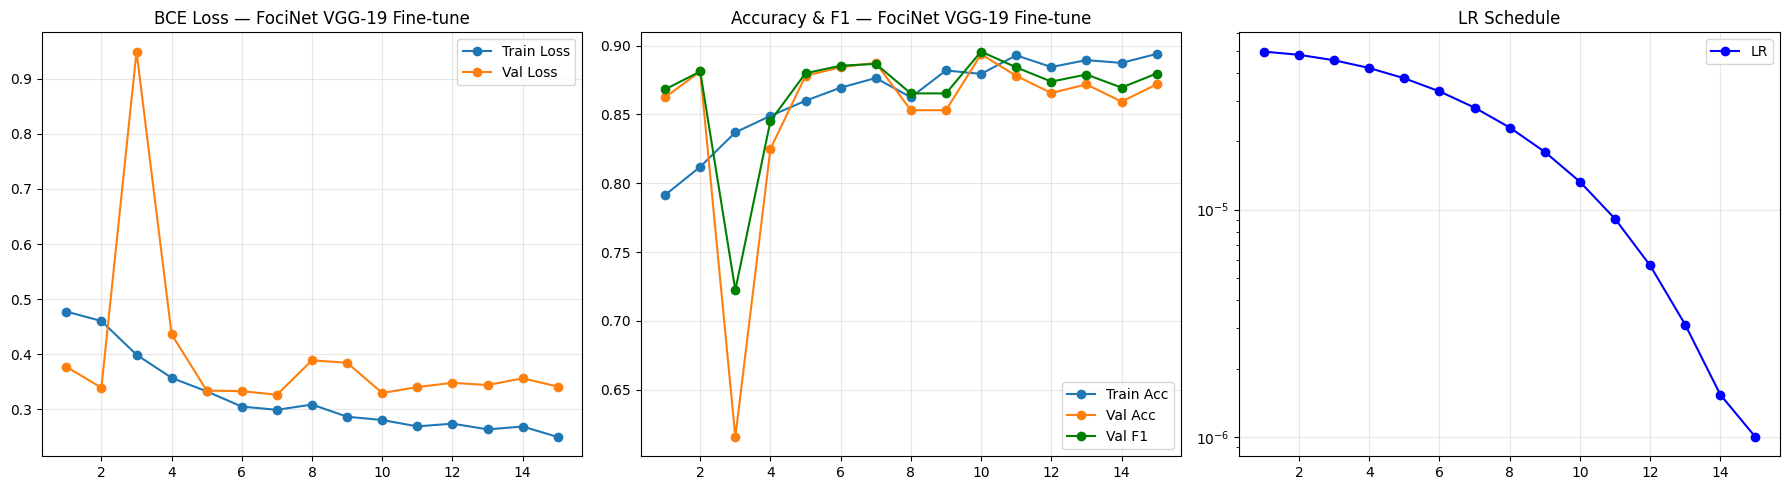

In [ ]:
# =========================
# 4. MODEL — VGG-19 with pretrained conv, binary FC head
# =========================
class FociNet_VGG19_Finetune(nn.Module):
    def __init__(self, h5_path):
        super().__init__()

        vgg = models.vgg19(weights=None)

        vgg = load_vgg19_conv_weights_from_h5(vgg, h5_path)

        self.features = vgg.features
        self.avgpool  = vgg.avgpool   # AdaptiveAvgPool2d(7,7)

        for param in self.features.parameters():
            param.requires_grad = False
        print("🔒 All conv layers frozen — only FC head will be trained.")

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),   
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),           
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 1)              
        )

        # Xavier init on FC head
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x.squeeze(-1)

# =========================
# 5. TRAINING LOOP
# =========================
def main():
    os.makedirs(os.path.dirname(CFG["save_path"]), exist_ok=True)
    os.makedirs(CFG["output_dir"], exist_ok=True)

    train_loader = DataLoader(
        FociNetDataset(CFG["train_csv"], CFG["image_size"], is_train=True),
        batch_size=CFG["batch_size"], shuffle=True,
        collate_fn=safe_collate, num_workers=0
    )
    val_loader = DataLoader(
        FociNetDataset(CFG["val_csv"], CFG["image_size"], is_train=False),
        batch_size=CFG["batch_size"], shuffle=False,
        collate_fn=safe_collate, num_workers=0
    )

    model = FociNet_VGG19_Finetune(VGG_H5_PATH).to(DEVICE)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable parameters : {trainable:,} / {total:,}")

    # Adam — FociNet paper uses Adam, no weight decay
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=CFG["lr"],
        weight_decay=CFG["wd"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CFG["epochs"], eta_min=1e-6
    )

    criterion = nn.BCEWithLogitsLoss()

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  [],
        "val_f1":     [], "lr":       []
    }
    best_f1 = 0.0

    print("\nStarting Training...")
    for epoch in range(CFG["epochs"]):

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]", leave=False):
            if batch is None: continue
            x, y = [b.to(DEVICE) for b in batch]
            optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            loss.backward()
            optimizer.step()

            B          = x.size(0)
            t_loss    += loss.item() * B
            t_correct += ((logits >= 0.0).float() == y).sum().item()
            t_total   += B

        # ── Val ───────────────────────────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        v_preds_all, v_labels_all  = [], []

        with torch.no_grad():
            for batch in val_loader:
                if batch is None: continue
                x, y   = [b.to(DEVICE) for b in batch]
                logits = model(x)
                loss   = criterion(logits, y)

                B          = x.size(0)
                v_loss    += loss.item() * B
                v_correct += ((logits >= 0.0).float() == y).sum().item()
                v_total   += B

                v_preds_all.extend((logits >= 0.0).float().cpu().numpy())
                v_labels_all.extend(y.cpu().numpy())

        scheduler.step()

        lr_now         = optimizer.param_groups[0]["lr"]
        train_loss_avg = t_loss    / t_total
        val_loss_avg   = v_loss    / max(v_total, 1)
        train_acc_avg  = t_correct / t_total
        val_acc_avg    = v_correct / max(v_total, 1)
        val_f1         = sk_f1(v_labels_all, v_preds_all, zero_division=0)

        history["train_loss"].append(train_loss_avg)
        history["val_loss"].append(val_loss_avg)
        history["train_acc"].append(train_acc_avg)
        history["val_acc"].append(val_acc_avg)
        history["val_f1"].append(val_f1)
        history["lr"].append(lr_now)

        print(
            f"Epoch {epoch+1:02d}: "
            f"Train Loss={train_loss_avg:.4f}, Acc={train_acc_avg:.4f} | "
            f"Val Loss={val_loss_avg:.4f}, Acc={val_acc_avg:.4f}, F1={val_f1:.4f} | "
            f"LR: {lr_now:.2e}"
        )

        if val_f1 >= best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), CFG["save_path"])
            print(f"  -> ✅ Saved Best Model (Val F1: {best_f1:.4f})")

        torch.save(model.state_dict(), f"/content/ckpt_focinet_ft_epoch_{epoch+1}.pth")

    # ── Copy checkpoints to Drive ─────────────────────────────────────────────
    print("\nCopying per-epoch checkpoints to Drive...")
    for ep in range(1, CFG["epochs"] + 1):
        local_ckpt = f"/content/ckpt_focinet_ft_epoch_{ep}.pth"
        if os.path.exists(local_ckpt):
            shutil.copy2(
                local_ckpt,
                CFG["save_path"].replace(".pth", f"_epoch_{ep}.pth")
            )
            os.remove(local_ckpt)
    print("✅ All checkpoints copied to Drive.")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, CFG["epochs"] + 1)

    ax[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
    ax[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o")
    ax[0].set_title("BCE Loss — FociNet VGG-19 Fine-tune")
    ax[0].legend(); ax[0].grid(True, alpha=0.3)

    ax[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
    ax[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   marker="o")
    ax[1].plot(epochs_range, history["val_f1"],    label="Val F1",    marker="o", color="green")
    ax[1].set_title("Accuracy & F1 — FociNet VGG-19 Fine-tune")
    ax[1].legend(); ax[1].grid(True, alpha=0.3)

    ax[2].plot(epochs_range, history["lr"], label="LR", marker="o", color="blue")
    ax[2].set_title("LR Schedule")
    ax[2].set_yscale("log"); ax[2].legend(); ax[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = f"{CFG['output_dir']}/training_metrics_focinet_vgg19_finetune.png"
    plt.savefig(plot_path)
    print(f"\nTraining Complete! Best Val F1: {best_f1:.4f}")
    print(f"Plot saved to {plot_path}")


if __name__ == "__main__":
    main()

**eval**

In [ ]:
import os
import h5py
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)

# =========================
# 1. CONFIGURATION
# =========================
TEST_CSV = "/content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/test_dataset.csv"

CFG = {
    "batch_size":   32,
    "test_csv":     TEST_CSV,
    "model_ckpt":   "/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg19_finetune/baseline_model.pth",
    "output_dir":   "/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg19_finetune/eval_results/test_v01",
    "image_size":   256,   # FociNet uses 256×256
    "device":       torch.device("cuda" if torch.cuda.is_available() else "cpu"),
}

DEVICE = CFG["device"]
os.makedirs(CFG["output_dir"], exist_ok=True)

print(f"--- EVALUATION: FociNet VGG-19 Fine-tuned ---")
print(f"Checkpoint : {CFG['model_ckpt']}")
print(f"Test CSV   : {CFG['test_csv']}")

# =========================
# 2. PREPROCESSING — FociNet contrast stretching
# =========================
# Must match training preprocessing exactly
# FociNet: per-image contrast stretching, NOT mean/std normalisation

class FociNetPreprocess:
    def __init__(self, size=256):
        self.size = size

    def __call__(self, img_path):
        img  = Image.open(img_path).convert("RGB")
        img  = img.resize((self.size, self.size), Image.BICUBIC)
        arr  = np.array(img).astype(np.float32)
        p_low  = np.percentile(arr, 0.01)
        p_high = np.percentile(arr, 99.99)
        arr    = (arr - p_low) / (p_high - p_low + 1e-6)
        return np.clip(arr, 0.0, 1.0)   # (256, 256, 3) float32

class FociNetEvalDataset(Dataset):
    def __init__(self, csv_path, img_size=256):
        self.df         = pd.read_csv(csv_path)
        self.preprocess = FociNetPreprocess(size=img_size)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img_path = str(row["image_path"])
            arr      = self.preprocess(img_path)           # (256,256,3) float32
            pil      = Image.fromarray((arr * 255).astype(np.uint8))
            x        = torch.from_numpy(arr).permute(2, 0, 1).float()  # (3,256,256)
            y        = float(row["label"])
            return x, torch.tensor(y).float()
        except Exception: return None

def safe_collate_eval(batch):
    batch = [b for b in batch if b is not None]
    if not batch: return None
    xs, ys = zip(*batch)
    return torch.stack(xs), torch.stack(ys)

# =========================
# 3. MODEL — must mirror training exactly
# =========================
class FociNet_VGG19_Finetune(nn.Module):
    def __init__(self):
        super().__init__()
        vgg           = models.vgg19(weights=None)
        self.features = vgg.features
        self.avgpool  = vgg.avgpool
        for param in self.features.parameters():
            param.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x.squeeze(-1)

# =========================
# 4. EVALUATION
# =========================
def evaluate():
    test_loader = DataLoader(
        FociNetEvalDataset(CFG["test_csv"], CFG["image_size"]),
        batch_size=CFG["batch_size"],
        shuffle=False,
        collate_fn=safe_collate_eval,
        num_workers=0
    )

    model = FociNet_VGG19_Finetune().to(DEVICE)
    model.load_state_dict(
        torch.load(CFG["model_ckpt"], map_location=DEVICE),
        strict=True
    )
    model.eval()
    print("✅ Model loaded successfully")

    all_probs, all_labels = [], []

    print("Running inference...")
    with torch.no_grad():
        for batch in tqdm(test_loader):
            if batch is None: continue
            x, y   = [b.to(DEVICE) for b in batch]
            logits = model(x)
            probs  = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # ── Metrics ──────────────────────────────────────────────────────────────
    y_true  = np.array(all_labels).astype(int)
    y_probs = np.array(all_probs)
    y_preds = (y_probs >= 0.5).astype(int)

    acc     = accuracy_score(y_true, y_preds)
    prec    = precision_score(y_true, y_preds, zero_division=0)
    rec     = recall_score(y_true, y_preds, zero_division=0)
    f1      = f1_score(y_true, y_preds, zero_division=0)
    roc_auc = auc(*roc_curve(y_true, y_probs)[:2])

    print("\n" + "="*50)
    print("  RESULTS — FociNet VGG-19 Fine-tuned")
    print("="*50)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC AUC   : {roc_auc:.4f}")
    print("="*50)

    # Save metrics
    with open(os.path.join(CFG["output_dir"], "metrics.txt"), "w") as f:
        f.write("Model      : FociNet VGG-19 (fine-tuned on culture_only_v02)\n")
        f.write("Backbone   : FociNet pretrained conv weights from VGG.h5\n")
        f.write("Preprocessing: FociNet contrast stretching (0.01% saturated)\n")
        f.write(f"Checkpoint : {CFG['model_ckpt']}\n")
        f.write(f"Test CSV   : {CFG['test_csv']}\n\n")
        f.write(f"Accuracy   : {acc:.4f}\n")
        f.write(f"Precision  : {prec:.4f}\n")
        f.write(f"Recall     : {rec:.4f}\n")
        f.write(f"F1 Score   : {f1:.4f}\n")
        f.write(f"ROC AUC    : {roc_auc:.4f}\n")

    # ── Confusion matrix ─────────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Healthy", "Damaged"],
                yticklabels=["Healthy", "Damaged"])
    plt.xlabel("Predicted"); plt.ylabel("Ground Truth")
    plt.title("Confusion Matrix — FociNet VGG-19 Fine-tuned")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG["output_dir"], "confusion_matrix.png"))
    plt.close()

    # ── ROC curve ────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — FociNet VGG-19 Fine-tuned")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG["output_dir"], "roc_curve.png"))
    plt.close()

    print(f"\n✅ Done. Results saved to:\n{CFG['output_dir']}")


if __name__ == "__main__":
    evaluate()

--- EVALUATION: FociNet VGG-19 Fine-tuned ---
Checkpoint : /content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg19_finetune/baseline_model.pth
Test CSV   : /content/drive/MyDrive/FYP/natural foci ground truths/data/culture_only_v02/test_dataset.csv
✅ Model loaded successfully
Running inference...


  0%|          | 0/11 [00:00<?, ?it/s]


  RESULTS — FociNet VGG-19 Fine-tuned
  Accuracy  : 0.8602
  Precision : 0.8372
  Recall    : 0.8944
  F1 Score  : 0.8649
  ROC AUC   : 0.9340

✅ Done. Results saved to:
/content/drive/MyDrive/FYP/natural foci ground truths/models/focinet_vgg19_finetune/eval_results/test_v01


In [ ]:
# =========================================================
# SIGNIFICANCE TESTS: Proposed vs. FociNet0
# =========================================================


import json
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy import stats
try:
    from statsmodels.stats.contingency_tables import mcnemar
except ImportError:
    !pip install -q statsmodels
    from statsmodels.stats.contingency_tables import mcnemar

PROPOSED_PRED_DIR = "/content/drive/MyDrive/FYP/paper_revision_v01/eval_results"
FOCINET_PRED_DIR  = "/content/drive/MyDrive/FYP/paper_revision_v01/eval_results_focinet"
SIG_OUT_DIR       = FOCINET_PRED_DIR
N_SEEDS = 5
TAU = 0.5

per_seed_records = []

for seed in range(N_SEEDS):
    prop_csv = os.path.join(PROPOSED_PRED_DIR, f"seed_{seed}", "predictions_test.csv")
    foci_csv = os.path.join(FOCINET_PRED_DIR,  f"seed_{seed}", "predictions_test.csv")
    if not (os.path.exists(prop_csv) and os.path.exists(foci_csv)):
        raise FileNotFoundError(
            f"Missing predictions for seed {seed}:\n  proposed: {prop_csv}\n  focinet:  {foci_csv}\n"
            "Run the proposed-method eval and the FociNet multi-seed eval first."
        )
    dp = pd.read_csv(prop_csv)
    df = pd.read_csv(foci_csv)
    merged = dp.merge(df, on="image_path", suffixes=("_prop", "_foci"))
    if len(merged) == 0:
        raise RuntimeError(f"No overlapping image_path values for seed {seed}.")

    # Sanity: labels should match across the two files.
    assert (merged["label_prop"] == merged["label_foci"]).all(), \
        f"Label mismatch for seed {seed}: prediction CSVs disagree on ground truth."
    y     = merged["label_prop"].values.astype(int)
    p_pr  = merged["prob_prop"].values
    p_fo  = merged["prob_foci"].values

    yh_pr = (p_pr >= TAU).astype(int)
    yh_fo = (p_fo >= TAU).astype(int)

    # McNemar contingency on "is the prediction correct?"
    pr_ok = (yh_pr == y)
    fo_ok = (yh_fo == y)
    n_a = int(( pr_ok &  fo_ok).sum())     # both correct
    n_b = int(( pr_ok & ~fo_ok).sum())     # proposed right, focinet wrong
    n_c = int((~pr_ok &  fo_ok).sum())     # focinet right, proposed wrong
    n_d = int((~pr_ok & ~fo_ok).sum())     # both wrong
    table = [[n_a, n_b], [n_c, n_d]]
    # Use exact binomial when discordants small, chi-square otherwise.
    use_exact = (n_b + n_c) < 25
    mc = mcnemar(table, exact=use_exact, correction=True)

    auc_pr = float(roc_auc_score(y, p_pr))
    auc_fo = float(roc_auc_score(y, p_fo))
    ap_pr  = float(average_precision_score(y, p_pr))
    ap_fo  = float(average_precision_score(y, p_fo))

    per_seed_records.append({
        "seed": seed, "n_test": len(merged),
        "mcnemar_b_prop_right_foci_wrong": n_b,
        "mcnemar_c_foci_right_prop_wrong": n_c,
        "mcnemar_statistic": float(mc.statistic) if mc.statistic is not None else None,
        "mcnemar_pvalue": float(mc.pvalue),
        "mcnemar_test":   "exact" if use_exact else "chi2-corrected",
        "roc_auc_proposed": auc_pr, "roc_auc_focinet": auc_fo,
        "pr_auc_proposed":  ap_pr,  "pr_auc_focinet":  ap_fo,
    })
    print(f"seed {seed}: n={len(merged)}  b(prop>foci)={n_b}  c(foci>prop)={n_c}  "
          f"McNemar p={mc.pvalue:.4g} ({'exact' if use_exact else 'chi2'})  "
          f"AUC: prop {auc_pr:.4f} vs foci {auc_fo:.4f}")


prop_aucs = np.array([r["roc_auc_proposed"] for r in per_seed_records])
foci_aucs = np.array([r["roc_auc_focinet"]  for r in per_seed_records])
prop_aps  = np.array([r["pr_auc_proposed"]  for r in per_seed_records])
foci_aps  = np.array([r["pr_auc_focinet"]   for r in per_seed_records])

# Paired t-test (paired over the 5 seeds).
t_auc, p_auc = stats.ttest_rel(prop_aucs, foci_aucs)
t_ap,  p_ap  = stats.ttest_rel(prop_aps,  foci_aps)

# Wilcoxon signed-rank as a non-parametric companion (small-n robustness).
try:
    w_auc, pw_auc = stats.wilcoxon(prop_aucs, foci_aucs)
    w_ap,  pw_ap  = stats.wilcoxon(prop_aps,  foci_aps)
except ValueError:
    w_auc = pw_auc = w_ap = pw_ap = float("nan")

# Pooled McNemar across seeds (treat seeds as one bigger paired sample).
pooled_b = sum(r["mcnemar_b_prop_right_foci_wrong"] for r in per_seed_records)
pooled_c = sum(r["mcnemar_c_foci_right_prop_wrong"] for r in per_seed_records)
pooled_table = [[0, pooled_b], [pooled_c, 0]]   # only discordants matter
pooled_mc = mcnemar(pooled_table, exact=False, correction=True)

results = {
    "config": {"n_seeds": N_SEEDS, "tau": TAU},
    "per_seed": per_seed_records,
    "paired_t_test_roc_auc": {
        "diff_mean": float(np.mean(prop_aucs - foci_aucs)),
        "diff_sd":   float(np.std(prop_aucs - foci_aucs, ddof=1)),
        "t_statistic": float(t_auc), "p_value": float(p_auc),
    },
    "paired_t_test_pr_auc": {
        "diff_mean": float(np.mean(prop_aps - foci_aps)),
        "diff_sd":   float(np.std(prop_aps - foci_aps, ddof=1)),
        "t_statistic": float(t_ap), "p_value": float(p_ap),
    },
    "wilcoxon_roc_auc": {"statistic": float(w_auc), "p_value": float(pw_auc)},
    "wilcoxon_pr_auc":  {"statistic": float(w_ap),  "p_value": float(pw_ap)},
    "pooled_mcnemar": {
        "b_prop_right_foci_wrong": int(pooled_b),
        "c_foci_right_prop_wrong": int(pooled_c),
        "statistic": float(pooled_mc.statistic) if pooled_mc.statistic is not None else None,
        "p_value":   float(pooled_mc.pvalue),
        "note": "Sum of discordant pairs across all 5 seed-pairs; "
                "treats seeds as one paired sample.",
    },
}
with open(os.path.join(SIG_OUT_DIR, "significance_tests.json"), "w") as f:
    json.dump(results, f, indent=2)

